Environment: velocity

In [250]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import scipy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy
import decoupler
import scvelo
import IPython
import single_cell_analysis
import mpl_toolkits.axes_grid1

In [270]:
from importlib import reload

single_cell_analysis = reload(single_cell_analysis)

In [4]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [7]:
# Load adata with raw counts and filter

adata_raw = scanpy.read_h5ad(
    working_directory+f"/splice_counts.h5ad"
)

# Calculate proportion of mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata_raw, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata_raw, inplace=True, percent_top=[], log1p=False
)

# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata_raw.obs["n_genes_by_counts"] >= 200)*(adata_raw.obs['total_counts'] <= 150000)*(adata_raw.obs['pct_counts_mt'] < 10)
adata_raw = adata_raw[included_cells]
print(adata_raw)

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'seurat_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [8]:
# Read ChIP-seq targets
base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

In [9]:
# Load bulk differential expression results

bulk_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_combined.csv", index_col=0)
bulk_metadata = pandas.read_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv", index_col=0)
samples = bulk_metadata.index.to_list()
reprogramming_columns = bulk_de.columns[bulk_de.columns.str.contains("Reprogramming")]
reprogramming_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_reprogramming.csv", index_col=0)
mef_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mef.csv", index_col=0)
mesc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mesc.csv", index_col=0)
ipsc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_ipsc.csv", index_col=0)

In [11]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, bulk_de.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Dead end_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Dead end_corr", ascending=False).head(100).index.to_numpy()

In [12]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [13]:
differentially_expressed_genes = reprogramming_de.loc[variable_in_bulk].query("padj < 0.05").index.to_numpy()

In [15]:
# Find Hic2 target TFs that change significantly during reprogramming

# All target transcription factors
target_tfs = numpy.intersect1d(shared_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

# Differentially expressed targets that are drivers of dead end
de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)

# Differentially expressed targets that are drivers of stem cells
de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)

# Activity of transcription factor targets

Hic2 OX decreased Klf4 expression in MEFs, but Hic2 KO decreased Klf4 expression in mESCs. Inconclusive, but since Hic2 is mainly a repressor a direct effect would probably be downregulation. The grouped trend plot suggests Klf4 is downregulated slightly by Hic2.

CollecTRI appears to be a useful database. Dorothea lacks many TFs such as Ovol1, Tlx2 and Hoxa7.

In [283]:
# Load CollecTRI database

collectri_df = decoupler.op.collectri(organism="mouse")

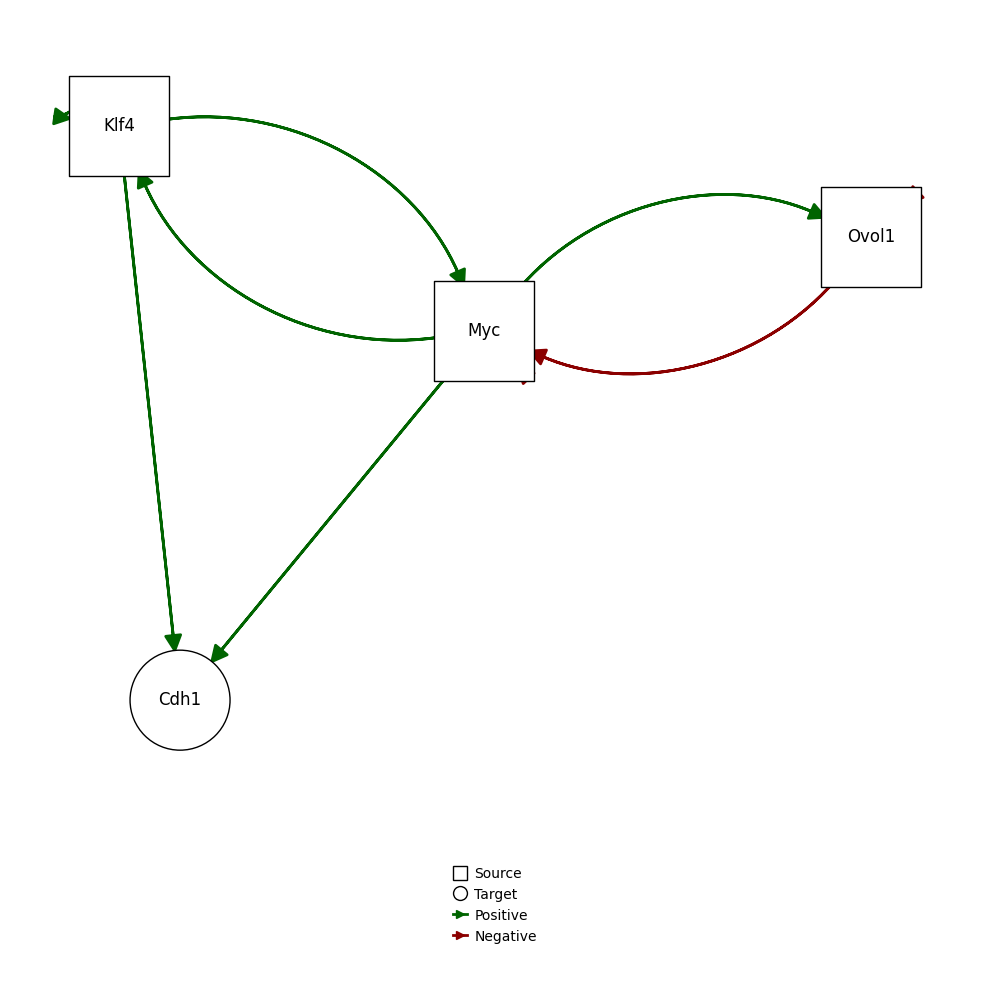

In [ ]:
ovol1_network_genes = ["Ovol1", "Myc", "Hic2", "Cdh1", "Klf4", "Tp53"] + collectri_df.query("source == \"Ovol1\"")["target"].to_list()

# filter the network to include only interactions internal to the gene set
filtered_network = collectri_df[(collectri_df["source"].isin(ovol1_network_genes)) & (collectri_df["target"].isin(ovol1_network_genes))]

# plot the network using the exact lists to bypass default truncation limits
decoupler.pl.network(
    net=filtered_network,
    figsize=(10, 10),
    vcenter=True,
    by_abs=True,
    size_node=100,
)

matplotlib.pyplot.show()

In [30]:
genes_of_interest = de_dead_end_drivers.tolist() + de_stem_cell_drivers.tolist() + ["Myc", "Cdh1", "Klf4", "Hic2"]

In [34]:
# Targets of Myc

collectri_df.query("source == \"Myc\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
861,Myc,Myc,-1.0,ExTRI;HTRI;TFactS,10467407;10606235;10625678;10657901;10672043;1...,PMID
1038,Myc,Cdh1,1.0,ExTRI;GEREDB,10523846;19176757;23364919;9632747,PMID
11396,Myc,Ovol1,1.0,ExTRI,16636146,default activation
14303,Myc,Klf4,1.0,ExTRI,19736564,default activation


In [35]:
# Regulating Myc

collectri_df.query("target == \"Myc\" and source in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
861,Myc,Myc,-1.0,ExTRI;HTRI;TFactS,10467407;10606235;10625678;10657901;10672043;1...,PMID
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
14302,Klf4,Myc,1.0,ExTRI;NTNU.Curated,17974960,default activation


In [54]:
# Targets of Klf4

collectri_df.query("source == \"Klf4\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
4817,Klf4,Klf4,1.0,ExTRI;NTNU.Curated,12087155;22337869;22854048,PMID
14302,Klf4,Myc,1.0,ExTRI;NTNU.Curated,17974960,default activation
19043,Klf4,Cdh1,1.0,ExTRI;NTNU.Curated;Pavlidis2021;TRRUST,20356845;21746878;22407433;22854048;23376074;2...,PMID


In [55]:
# Targets of Ovol1 among genes of interest

collectri_df.query("source == \"Ovol1\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID


In [56]:
# All Ovol1 targets

collectri_df.query("source == \"Ovol1\"")

,source,target,weight,resources,references,sign_decision
9262,Ovol1,Id2,1.0,ExTRI,15716349,default activation
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
11924,Ovol1,Gadd45a,1.0,ExTRI,16908841,default activation
11925,Ovol1,Gadd45b,1.0,ExTRI,16908841,default activation
11926,Ovol1,Lemd3,1.0,ExTRI,16908841,default activation
11927,Ovol1,Sgk1,1.0,ExTRI,16908841,default activation
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID
14851,Ovol1,Chuk,1.0,ExTRI,18268325,default activation
19305,Ovol1,Cdh2,1.0,ExTRI,20463035,default activation


In [57]:
ovol1_targets = collectri_df.query("source == \"Ovol1\"")["target"].to_numpy()
reprogramming_de.loc[ovol1_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Id2,1669.476516,0.709558,0.162943,4.354630,1.332918e-05,6.272011e-05
Myc,18952.909643,-0.137470,0.083679,-1.642832,1.004176e-01,1.902087e-01
Gadd45a,381.938162,0.402600,0.109673,3.670918,2.416813e-04,9.069282e-04
Gadd45b,716.061569,0.407813,0.208509,1.955854,5.048233e-02,1.075558e-01
Lemd3,1320.406975,0.078918,0.044580,1.770269,7.668232e-02,1.524299e-01
Sgk1,507.045197,-0.575744,0.169050,-3.405762,6.597961e-04,2.276504e-03
Ovol2,47.086576,-0.377526,0.246902,-1.529050,1.262522e-01,2.287184e-01
Ovol1,680.945017,-1.451013,0.185601,-7.817911,5.370714e-15,8.662382e-14
Chuk,2215.038586,0.308015,0.067620,4.555098,5.236122e-06,2.648868e-05
Cdh2,2414.041323,0.392772,0.135501,2.898653,3.747695e-03,1.099432e-02


Ovol1 is downregulated by Hic2, meaning targets with weight 1 should be downregulated and weight -1 upregulated. However, since Ovol1 is mainly a repressor all the ones determined by "default activation" are probably actually -1. All targets except Ovol1 itself, Ovol2, Myc and Sgk1 are upregulated in control suggesting that Ovol1 activity is indeed lower.

In [58]:
combined_driver_df.loc[numpy.intersect1d(ovol1_targets, combined_driver_df.index)]

,Full correlation,Early correlation,Late correlation,Control correlation,Hic2 correlation
gene_names,,,,,
Cdh2,-0.022867,-0.026045,-0.161326,0.129190,-0.463374
Gadd45a,0.102734,0.157742,0.137937,0.022360,0.123604
Gadd45b,0.314482,0.312153,0.046284,0.161942,0.108775
Id2,0.087804,0.088949,0.000491,0.087065,-0.109891
Myc,-0.344658,-0.211906,-0.548859,-0.297400,-0.262042
Ovol1,-0.420250,-0.397374,-0.469301,-0.354795,-0.097588
Sgk1,0.241924,0.086454,0.527254,0.329728,0.205173


In [59]:
tlx2_targets = collectri_df.query("source == \"Tlx2\"")["target"].to_numpy()
reprogramming_de.loc[tlx2_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ret,23.091996,-0.732177,0.280192,-2.613131,0.008972,0.024005
Slc8a3,10.349976,-0.587062,0.502865,-1.167435,0.243035,0.382594
Phox2b,24.553547,0.657880,0.440967,1.491903,0.135725,0.242204
Phox2a,183.685399,-0.313819,0.079289,-3.957926,0.000076,0.000312
Anxa5,7650.349077,-0.373951,0.105238,-3.553379,0.000380,0.001373


In [60]:
collectri_df.query("source == \"Zbtb7c\"")

,source,target,weight,resources,references,sign_decision
22846,Zbtb7c,Cdkn1a,-1.0,ExTRI;NTNU.Curated,22253232,PMID
23002,Zbtb7c,Fasn,1.0,ExTRI;NTNU.Curated,22331133,PMID


In [61]:
# Estimate activities of TF targets

# Manually assign weights of -1 to Ovol1 target since its a repressor
modified_collectri = collectri_df
modified_collectri.loc[modified_collectri["source"] == "Ovol1", "weight"] = -1.0

data = reprogramming_de[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=modified_collectri)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

In [62]:
dead_end_drivers_with_activities = numpy.intersect1d(de_dead_end_drivers, activities_df.index).tolist()
stem_cell_drivers_with_activities = numpy.intersect1d(de_stem_cell_drivers, activities_df.index).tolist()

In [63]:
# Activities of dead end drivers

activities_df.loc[dead_end_drivers_with_activities]

,Activity,Adjusted p-value
Ovol1,-0.490137,0.792728
Tlx2,-1.346953,0.392942


In [64]:
# Activities of stem cell drivers

activities_df.loc[stem_cell_drivers_with_activities]

,Activity,Adjusted p-value
Jarid2,-0.206512,0.911346
Rest,1.306590,0.412907
Tcf7l1,-0.343932,0.852160
Zfp42,2.184562,0.121749


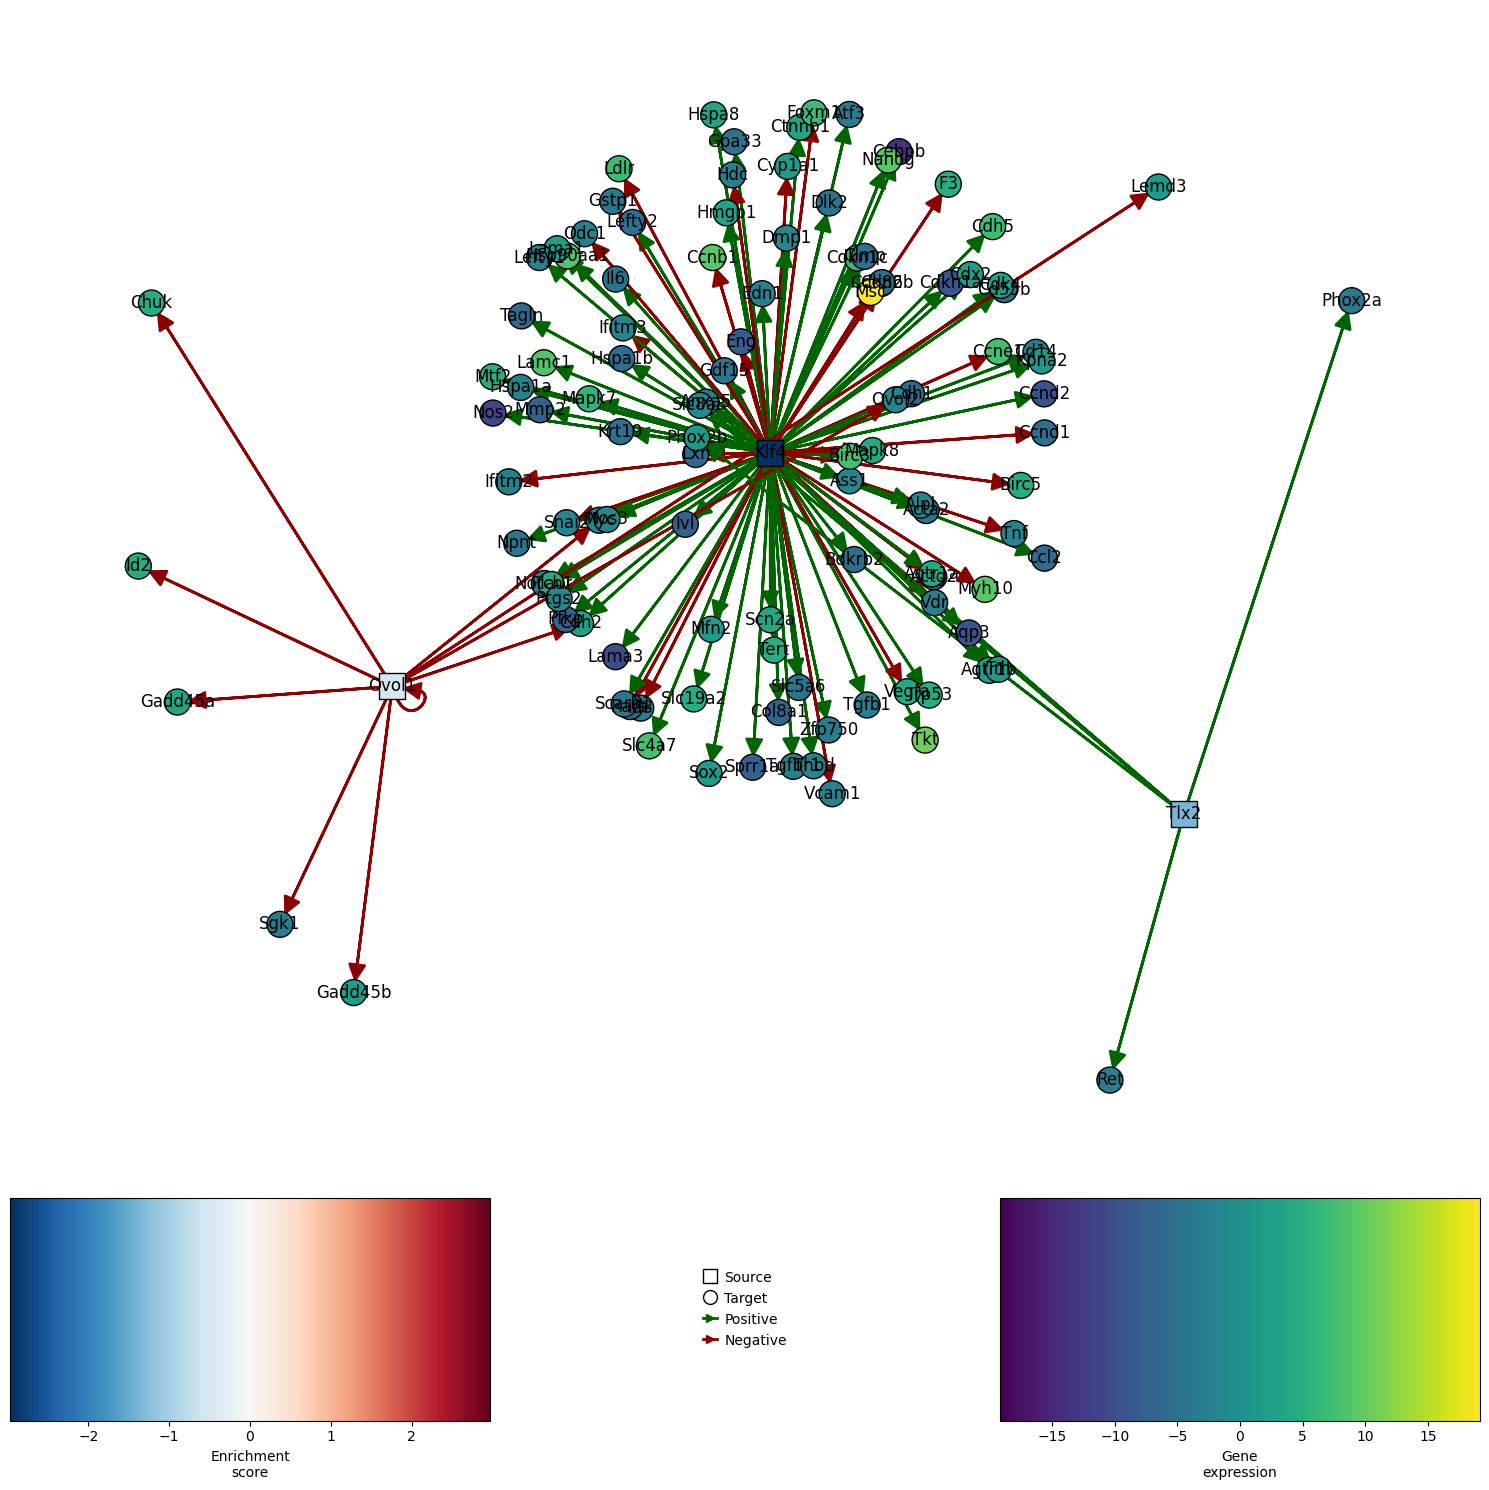

In [65]:
# Plot dead end network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

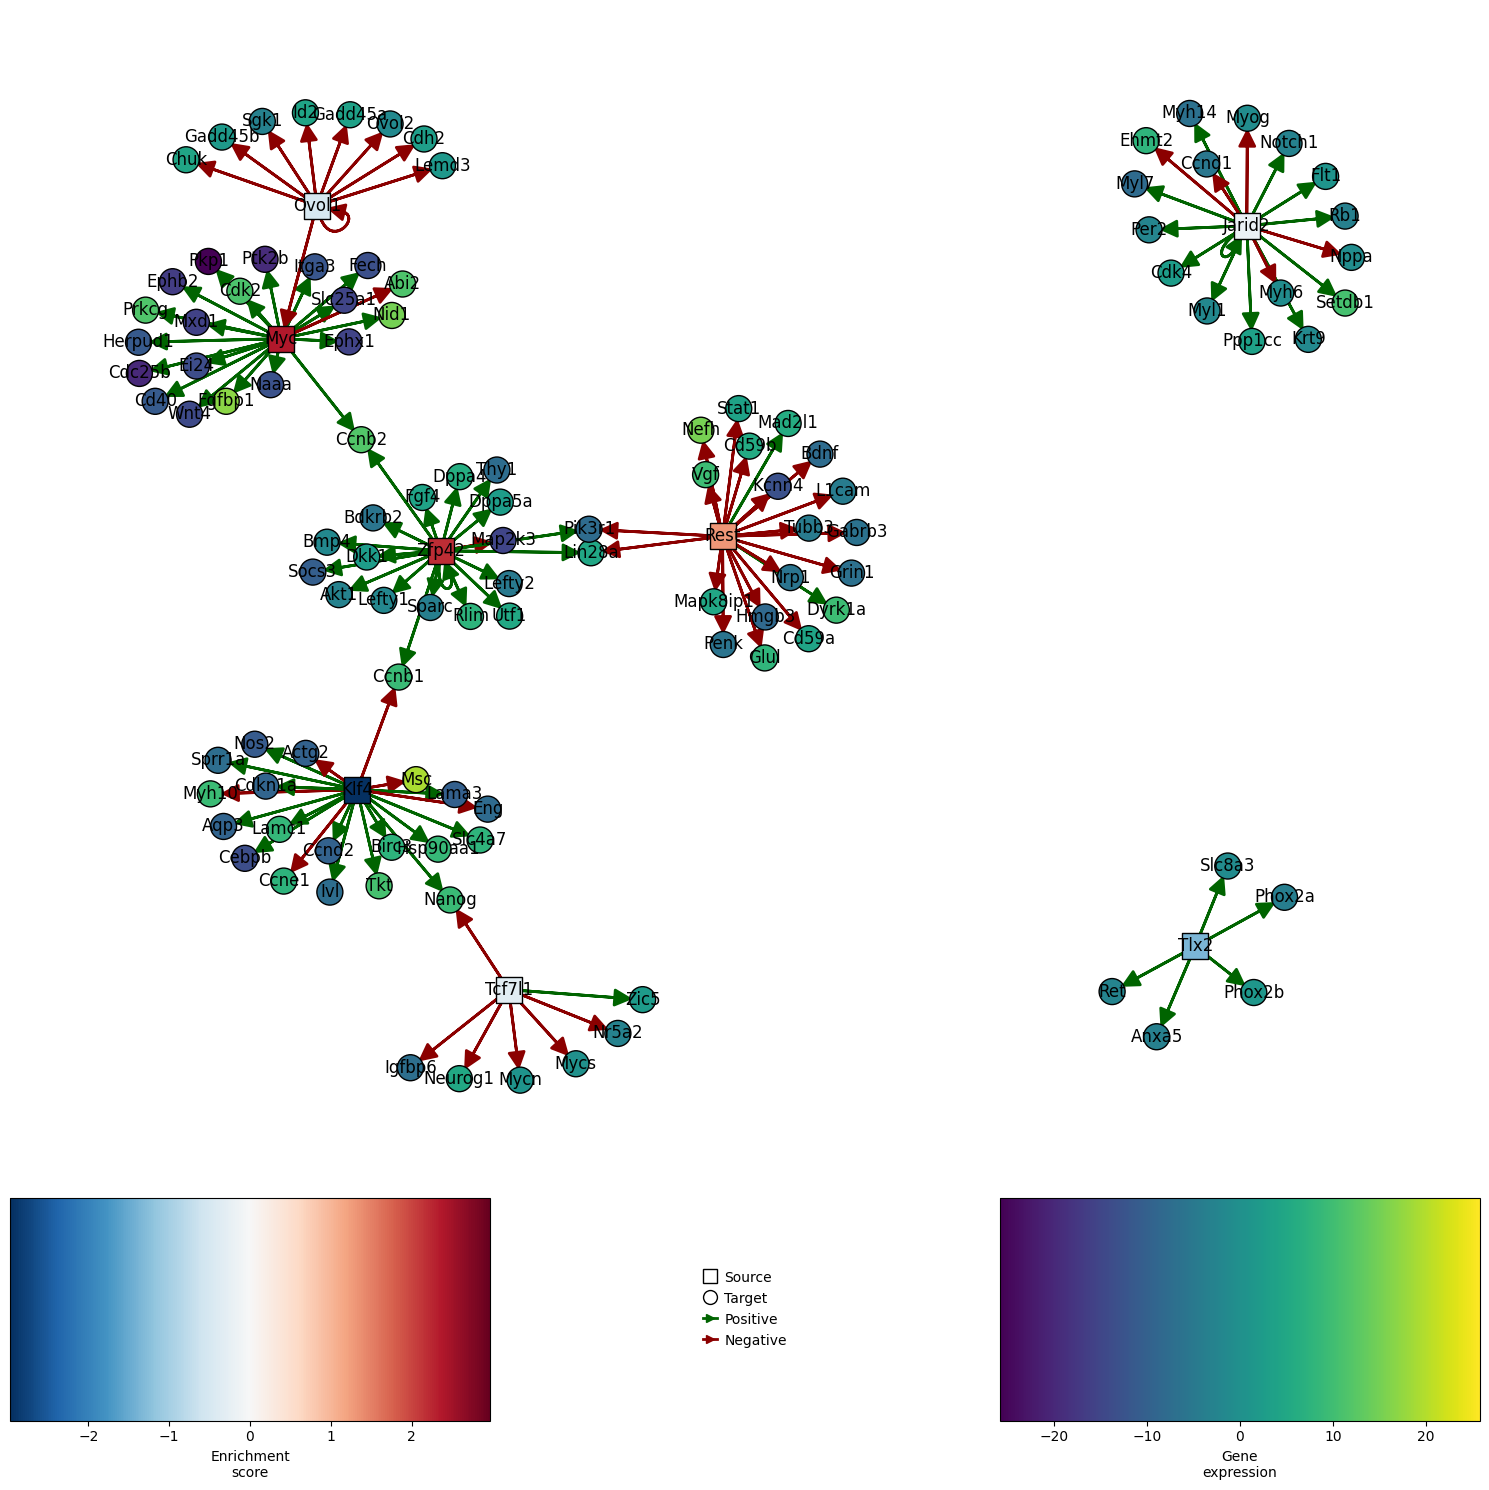

In [66]:
# Network with genes of interest

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=genes_of_interest,
    targets=20,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

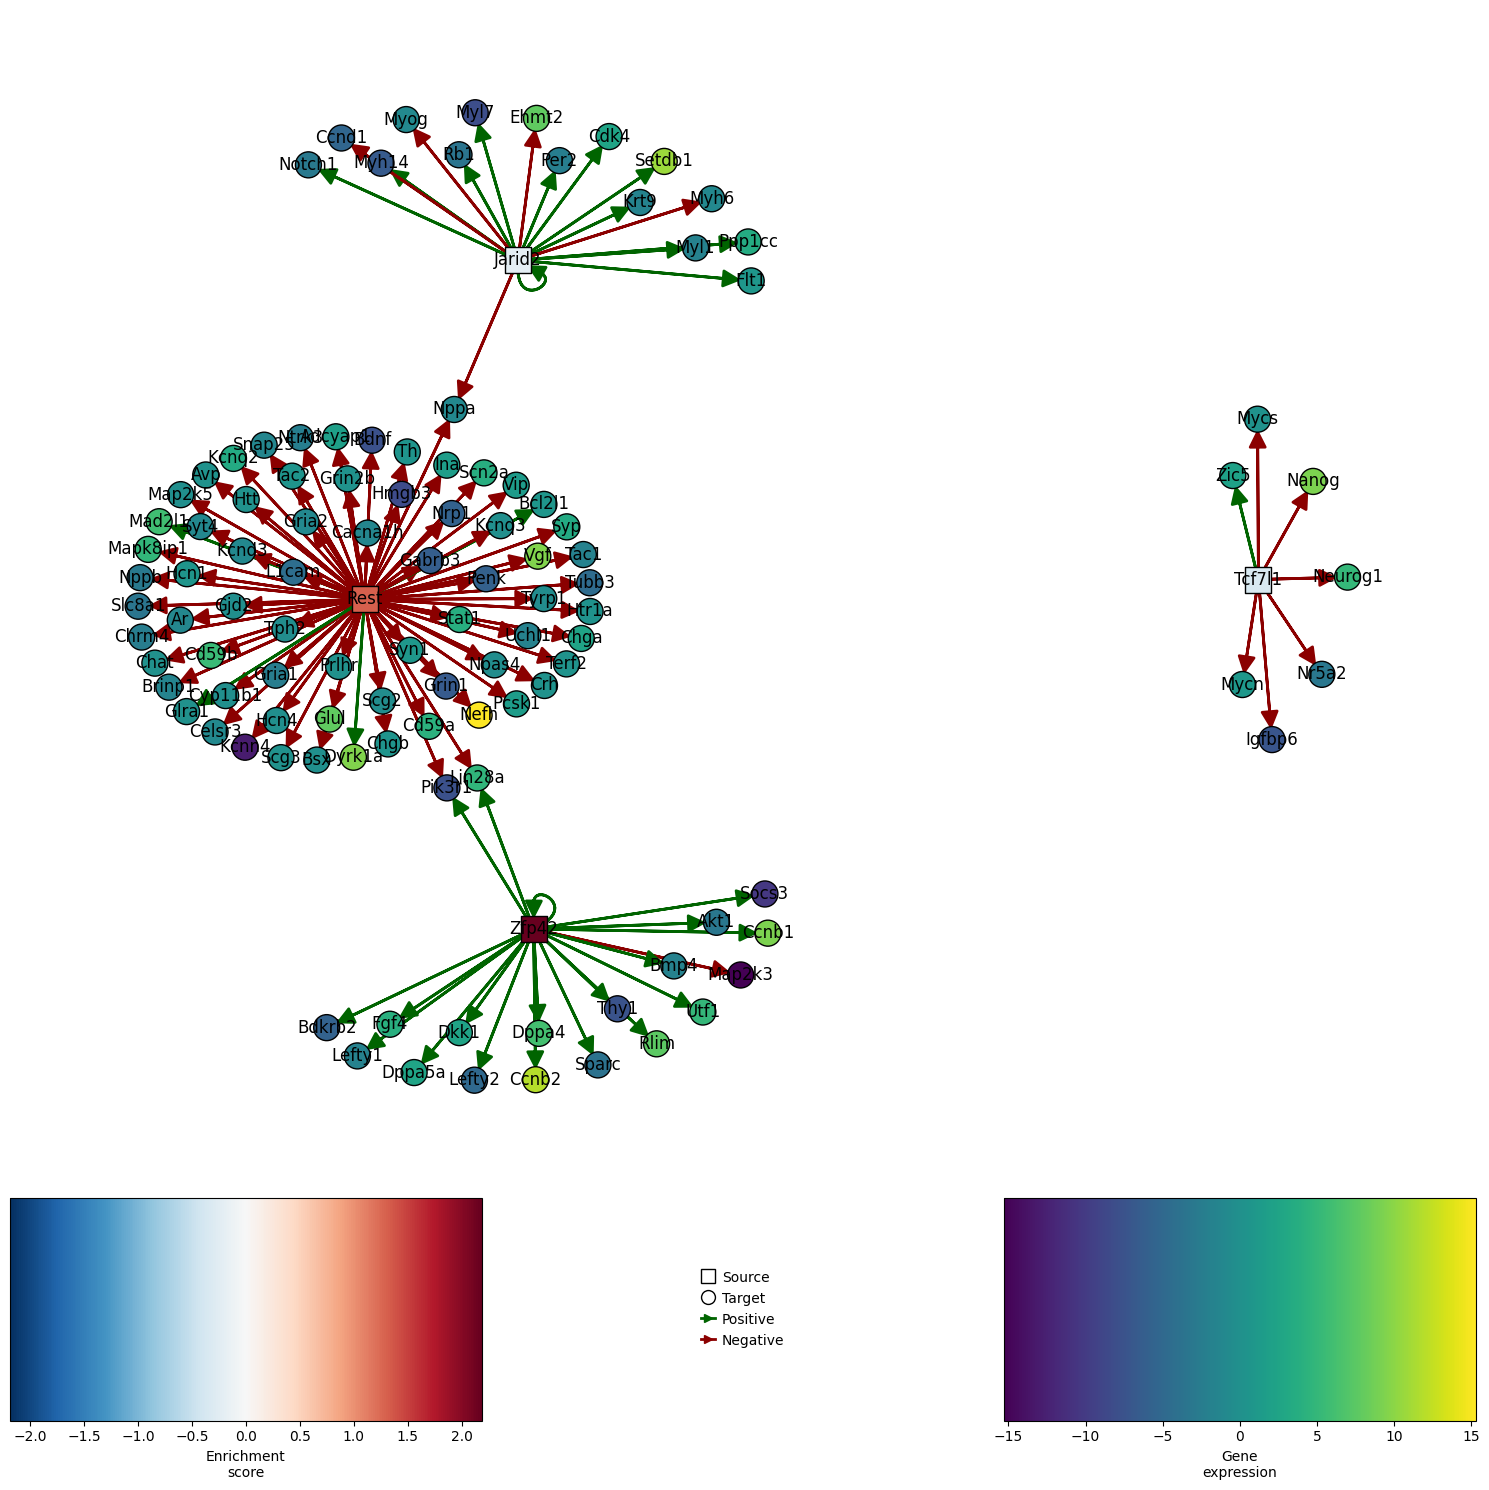

In [67]:
# Plot reprogramming network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=stem_cell_drivers_with_activities,
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

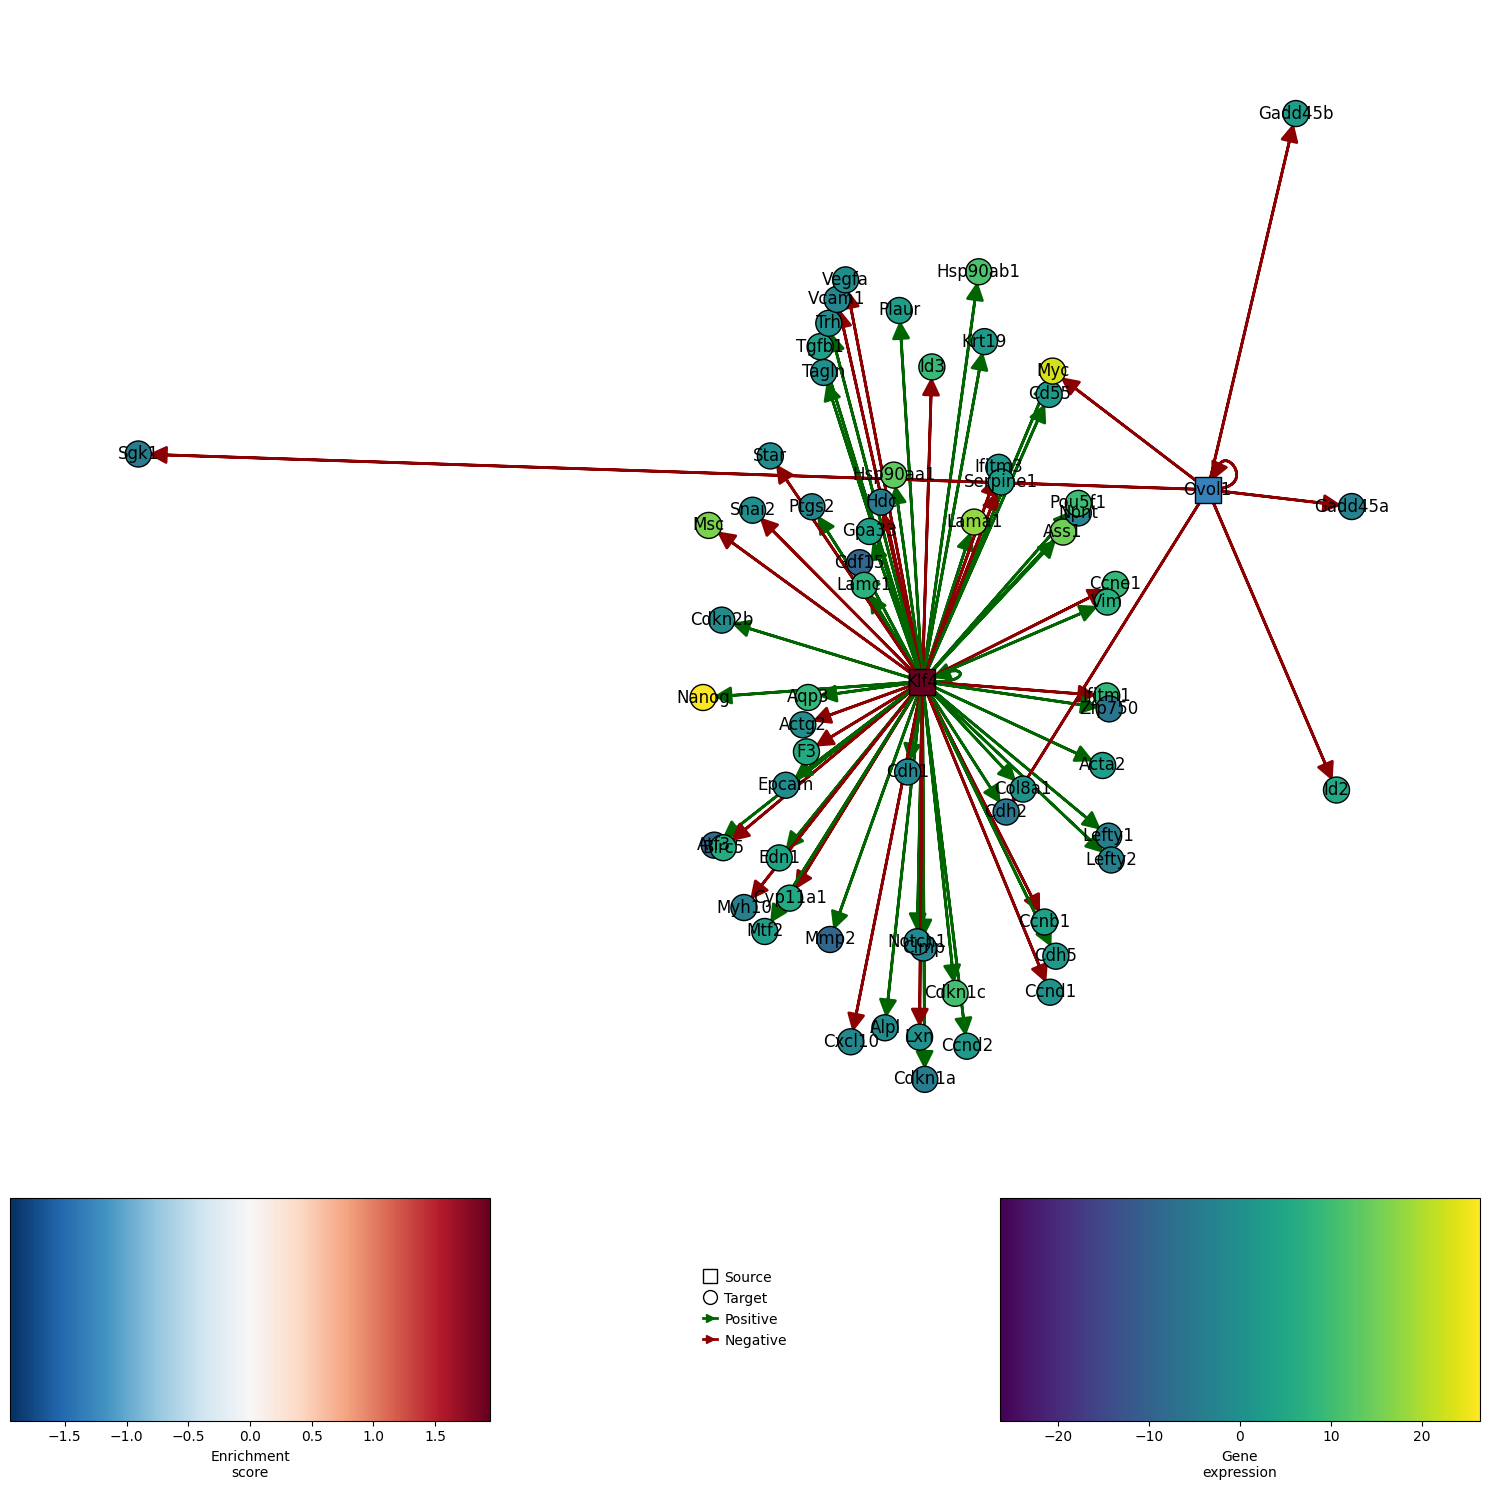

In [68]:
# Plot dead end network for mESCs

data = mesc_de[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

# Check if velocity for the dead end drivers correlate with Hic2 expression

In [74]:
cell_markers = gseapy.get_library("PanglaoDB_Augmented_2021", organism="Mouse")
epithelial_markers = numpy.array(pandas.Series(cell_markers["Epithelial Cells"]).str.capitalize())
keratinocyte_markers = numpy.array(pandas.Series(cell_markers["Keratinocytes"]).str.capitalize())
stem_cell_markers = numpy.array(pandas.Series(cell_markers["Pluripotent Stem Cells"]).str.capitalize())
fibroblast_markers = numpy.array(pandas.Series(cell_markers["Fibroblasts"]).str.capitalize())
neuron_markers = numpy.array(pandas.Series(cell_markers["Neurons"]).str.capitalize())
kupffer_markers = numpy.array(pandas.Series(cell_markers["Kupffer Cells"]).str.capitalize())

2026-03-12 17:45:13 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-12 17:45:13 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.PanglaoDB_Augmented_2021.gmt, use local file


In [75]:
# Score cell types

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(epithelial_markers, adata.var_names),
    score_name="epithelial_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(keratinocyte_markers, adata.var_names),
    score_name="keratinocyte_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(stem_cell_markers, adata.var_names),
    score_name="stem_cell_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(fibroblast_markers, adata.var_names),
    score_name="fibroblast_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(neuron_markers, adata.var_names),
    score_name="neuron_score",
    use_raw=False
)

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(kupffer_markers, adata.var_names),
    score_name="kupffer_score",
    use_raw=False
)

In [73]:
# Score apoptosis

go_database = gseapy.get_library("GO_Biological_Process_2025", organism="Mouse")
apoptosis_genes = numpy.array(pandas.Series(go_database["Positive Regulation of Apoptotic Process (GO:0043065)"]).str.capitalize())

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(apoptosis_genes, adata.var_names),
    score_name="apoptosis_score",
    use_raw=False
)

2026-03-12 17:45:10 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-12 17:45:10 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-03-12 17:45:10 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


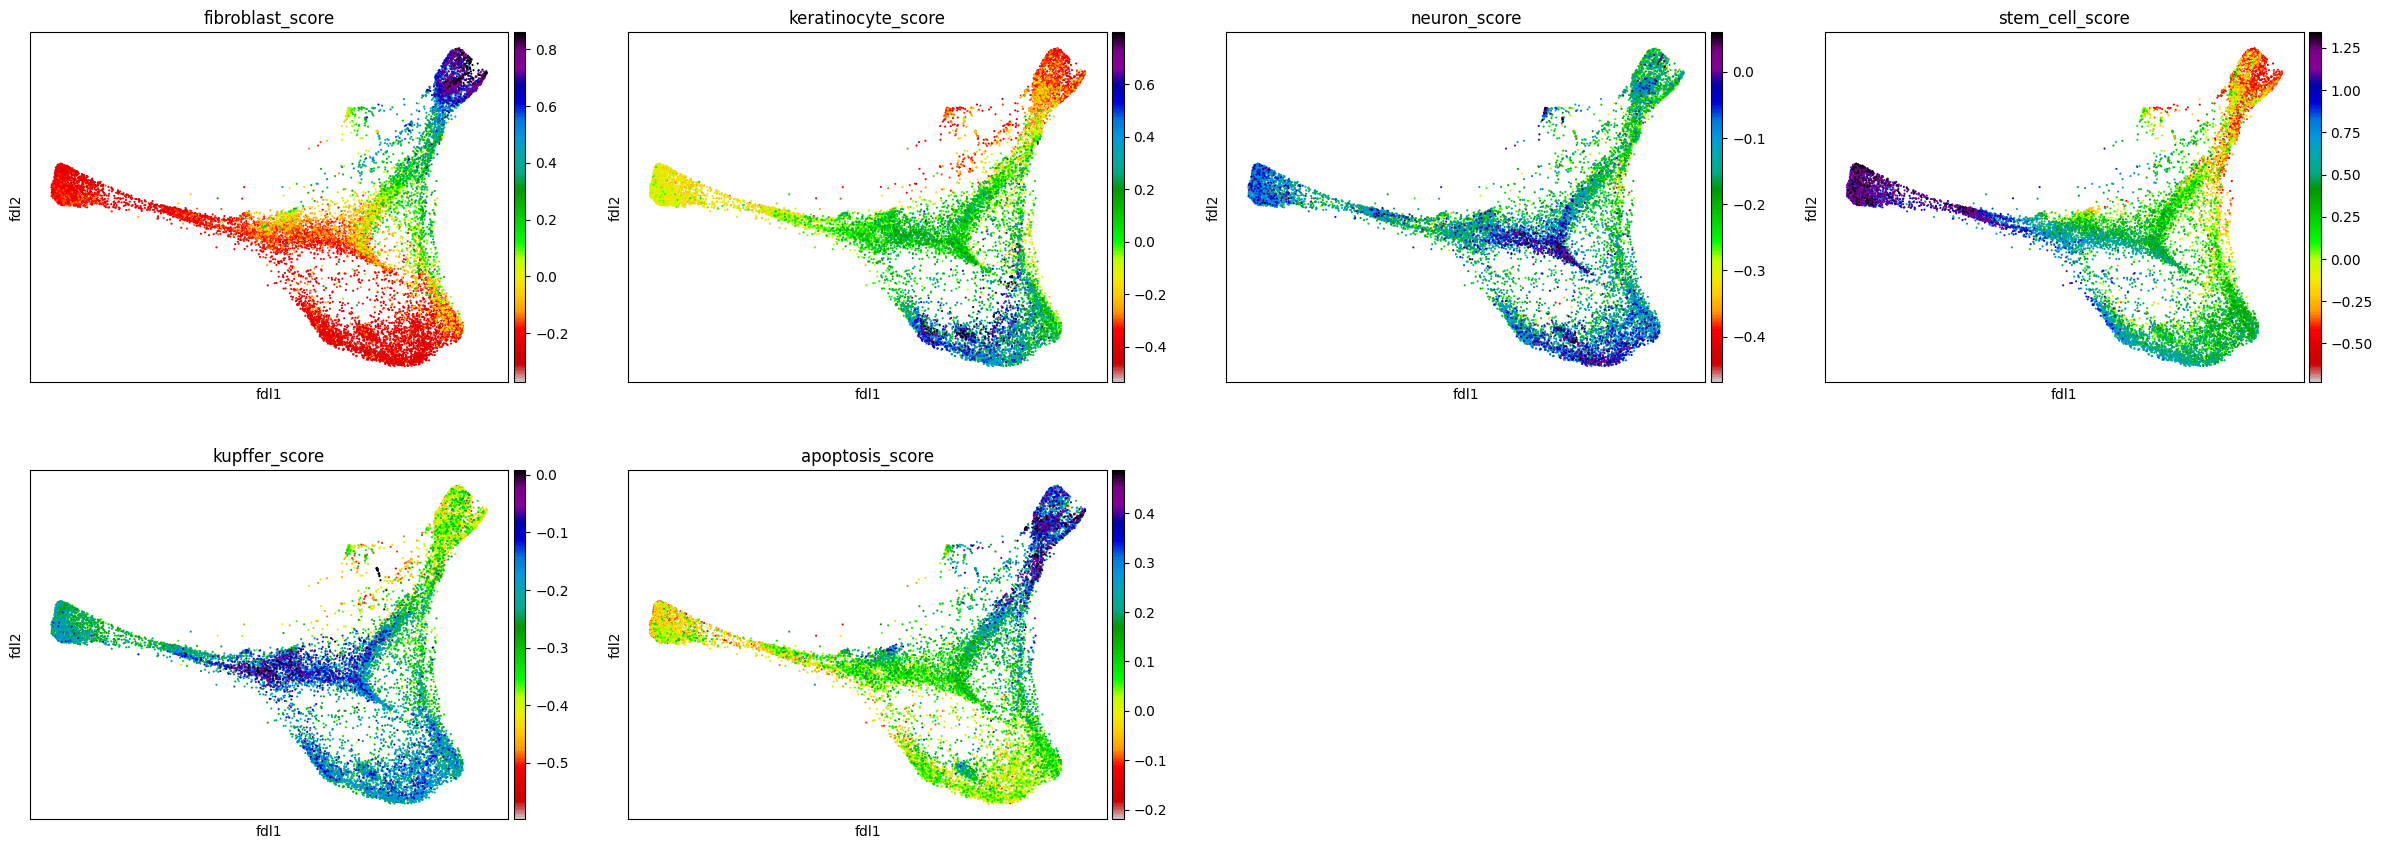

In [79]:
# Plot where cell types are found

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["fibroblast_score", "keratinocyte_score", "neuron_score", "stem_cell_score", "kupffer_score", "apoptosis_score"],
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99.5"
)

In [80]:
# To do: Score with UCell instead

In [286]:
collectri_df.query("source == \"Ovol1\" and weight==-1")

,source,target,weight,resources,references,sign_decision
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID


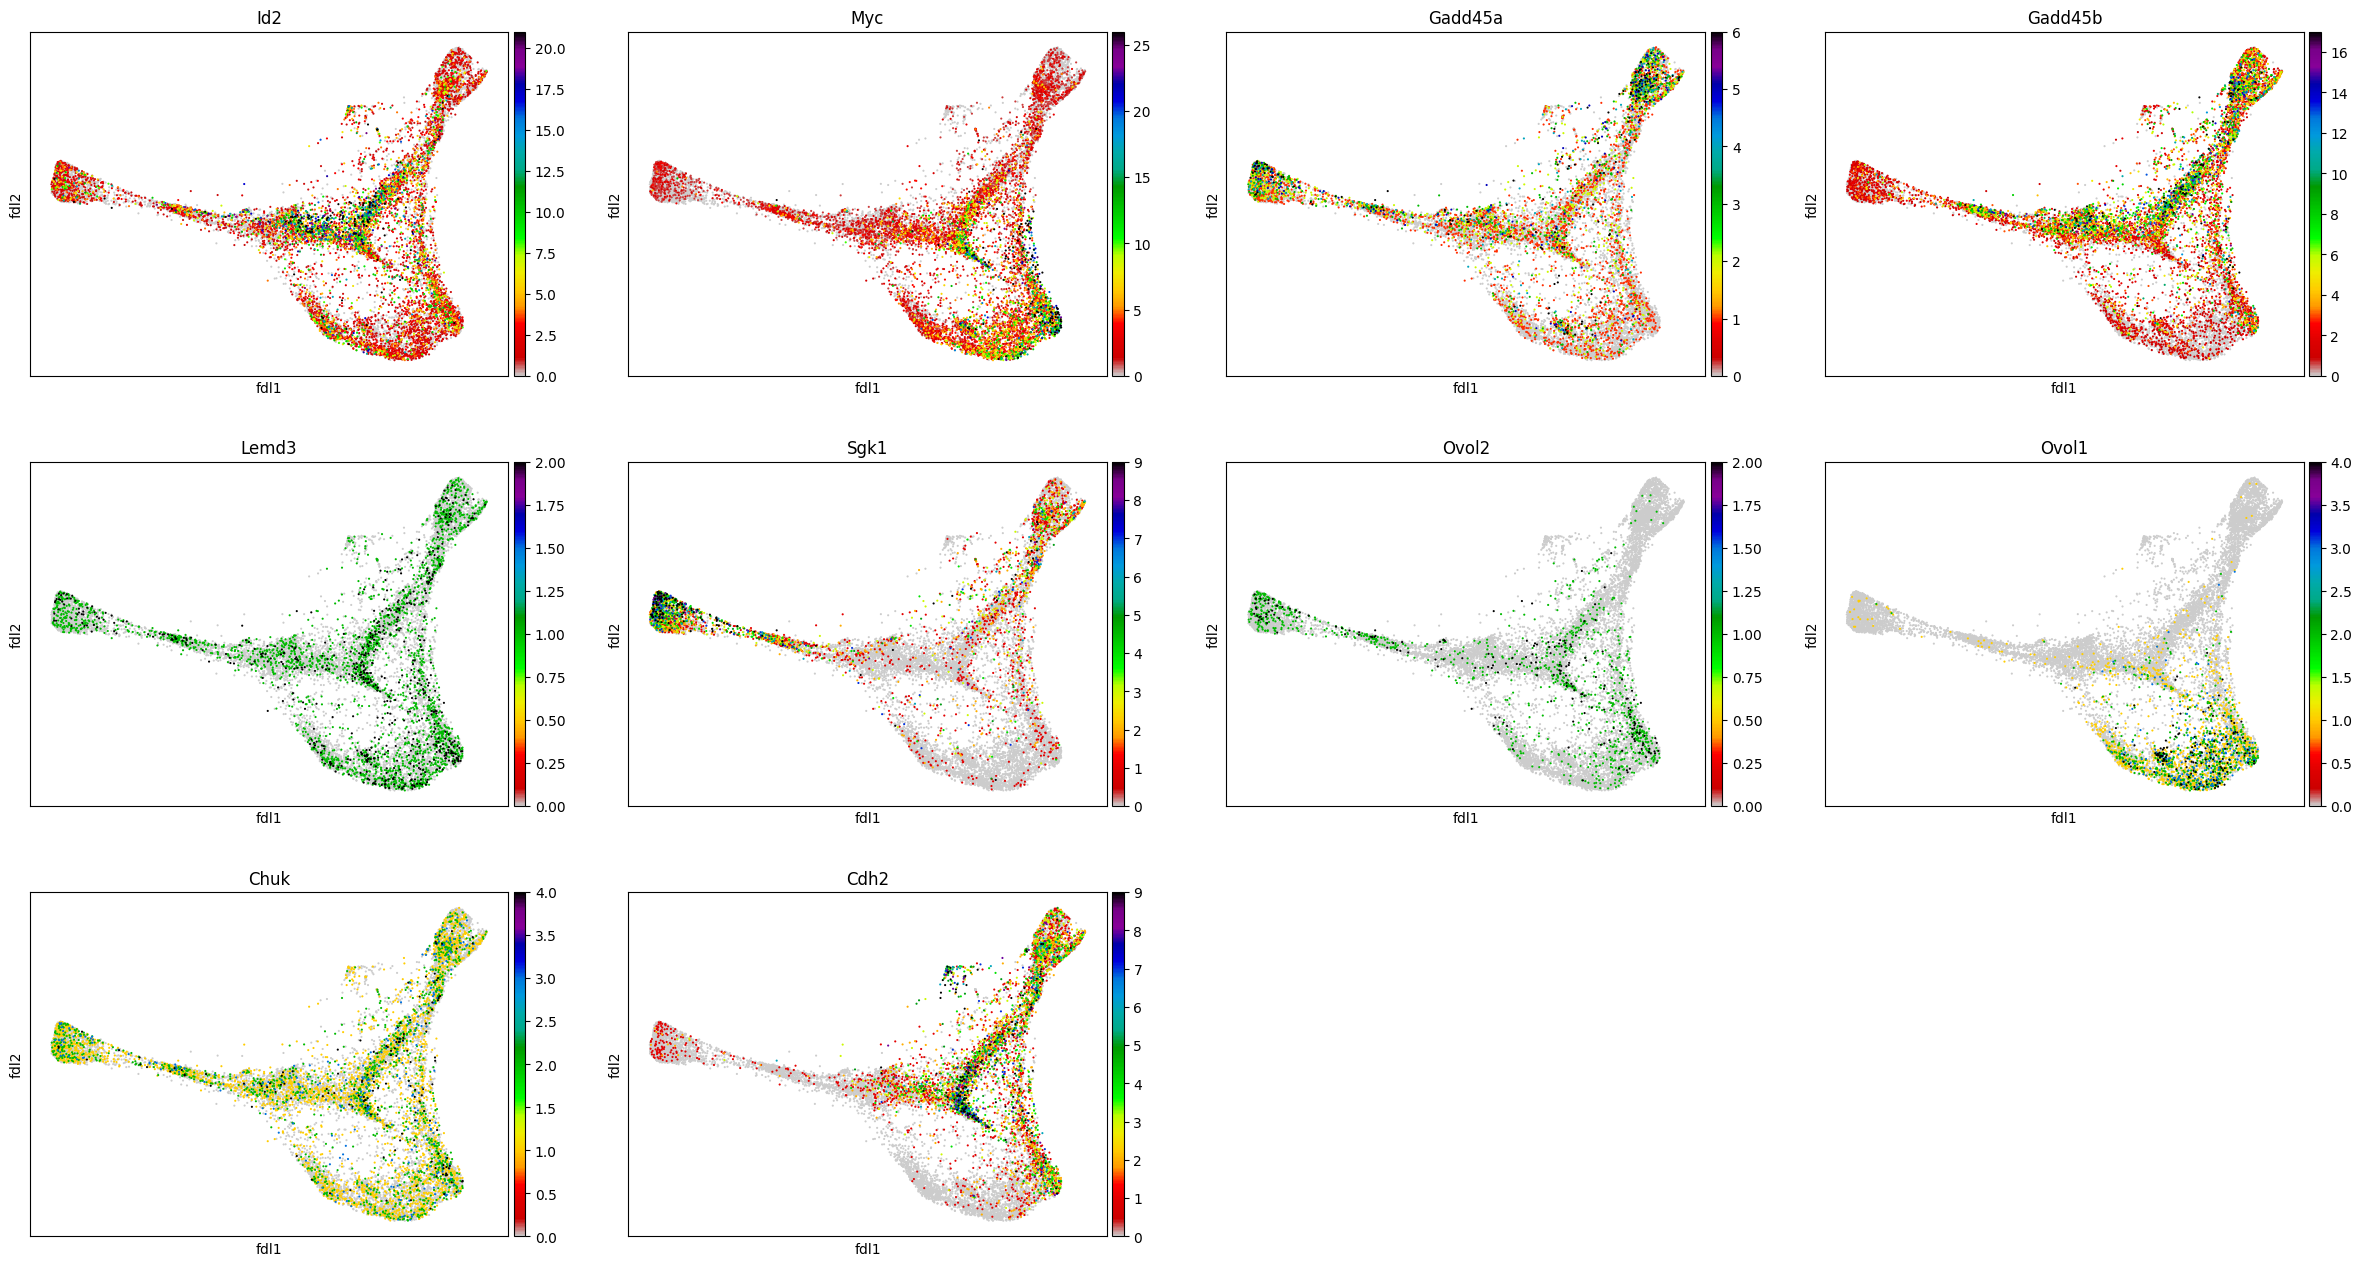

In [89]:
# Expression of Ovol1 targets and Cdh1

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=collectri_df.query("source == \"Ovol1\"")["target"].to_list(),
    cmap="nipy_spectral_r",
    show=True,
    vmax="p99"
)

Most targets appear to be anticorrelated with Ovol1. Ovol1 is mainly a repressor. The weights of +1 are all assigned by default, so it is likely that most or all targets are actually repressed by Ovol1. Thus, the absence of Ovol1 targets in the control trajectory is additional evidence for Ovol1 activity being higher. Even Ovol2 and Sgk1, which upregulated in control, are absent in the part with high Ovol1 expression.

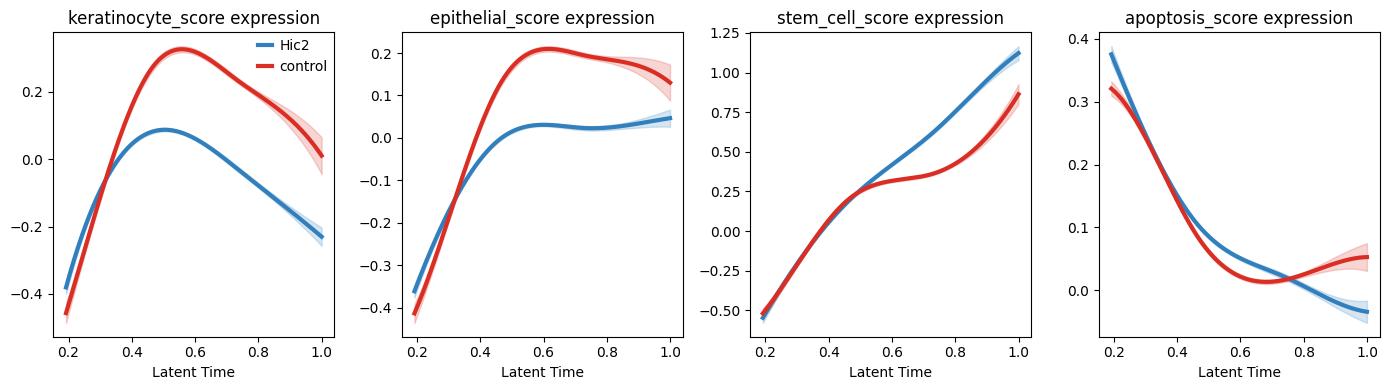

In [96]:
single_cell_analysis.plot_grouped_gene_trend(adata, genes=["keratinocyte_score", "epithelial_score", "stem_cell_score", "apoptosis_score"], layer="obs", groups=["Hic2", "control"])


# Correlations in cells

In [225]:
# Check correlation of Ovol1 with its potential targets

potential_ovol1_targets = collectri_df.query("source == \"Ovol1\"")["target"].to_list() + ["Zeb1", "Myc", "Tp63", "Ascl2", "Hic2", "Cdh1", "Klf4"]
potential_ovol1_targets = numpy.intersect1d(potential_ovol1_targets, adata.var_names)
potential_ovol1_targets

array(['Cdh1', 'Cdh2', 'Gadd45a', 'Gadd45b', 'Hic2', 'Id2', 'Klf4', 'Myc',
       'Ovol1', 'Sgk1', 'Zeb1'], dtype=object)

In [216]:
from importlib import reload

single_cell_analysis = reload(single_cell_analysis)

In [217]:
# Correlation with counts

control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []

for target in numpy.intersect1d(potential_ovol1_targets, adata.var_names):
    results = single_cell_analysis.calculate_correlation(adata, "Ovol1", target, layers=["Ms", "Ms"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

counts_correlations_df = pandas.DataFrame(index=numpy.intersect1d(potential_ovol1_targets, adata.var_names))
counts_correlations_df["control_corr"] = control_correlations
counts_correlations_df["control_p_value"] = control_correlations_p
counts_correlations_df["hic2_corr"] = hic2_correlations
counts_correlations_df["hic2_p_value"] = hic2_correlations_p
counts_correlations_df["total_corr"] = total_correlations
counts_correlations_df["total_p_value"] = total_correlations_p

counts_correlations_df.sort_values("total_corr", ascending=False)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Ovol1,1.000000,0.000000e+00,1.000000,0.000000e+00,1.000000,0.000000e+00
Cdh1,0.698716,0.000000e+00,0.187440,3.780097e-37,0.691466,0.000000e+00
Myc,0.454419,2.301821e-254,0.441653,5.628333e-216,0.582829,0.000000e+00
Klf4,0.009077,5.202620e-01,0.148127,1.124464e-23,0.147748,8.825378e-48
Hic2,0.178174,4.418195e-37,-0.023083,1.200522e-01,-0.253086,1.451211e-139
Id2,-0.254549,4.461068e-75,0.120567,3.682833e-16,-0.292340,1.217702e-187
Gadd45a,-0.262793,4.523709e-80,-0.190331,2.854484e-38,-0.383783,0.000000e+00
Cdh2,-0.675011,0.000000e+00,0.035967,1.540369e-02,-0.532234,0.000000e+00
Sgk1,-0.716500,0.000000e+00,-0.381488,4.076600e-157,-0.536971,0.000000e+00
Gadd45b,-0.627296,0.000000e+00,-0.480420,9.593412e-261,-0.731237,0.000000e+00


Suggests Ovol1 downregulates Id2, Gadd45a, Cdh2, Sgk1, Gadd45b and Zeb1

In [218]:
# Correlation with velocity

control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []

for target in numpy.intersect1d(potential_ovol1_targets, adata.var_names):
    results = single_cell_analysis.calculate_correlation(adata, "Ovol1", target, layers=["Ms", "sde_velocity"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

counts_correlations_df = pandas.DataFrame(index=numpy.intersect1d(potential_ovol1_targets, adata.var_names))
counts_correlations_df["control_corr"] = control_correlations
counts_correlations_df["control_p_value"] = control_correlations_p
counts_correlations_df["hic2_corr"] = hic2_correlations
counts_correlations_df["hic2_p_value"] = hic2_correlations_p
counts_correlations_df["total_corr"] = total_correlations
counts_correlations_df["total_p_value"] = total_correlations_p

counts_correlations_df.sort_values("total_corr", ascending=False)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Cdh1,0.690394,0.000000e+00,0.229750,2.030291e-55,0.701342,0.000000e+00
Gadd45b,0.562374,0.000000e+00,0.403786,1.570833e-177,0.650673,0.000000e+00
Gadd45a,0.258619,1.608569e-77,0.194971,4.138029e-40,0.384086,0.000000e+00
Hic2,0.098850,2.232454e-12,0.108257,2.643751e-13,0.287694,1.574743e-181
Zeb1,0.187492,6.056946e-41,0.113004,2.275803e-14,0.236596,1.033922e-121
Cdh2,0.169122,1.583829e-33,0.070447,2.036941e-06,0.157496,3.955573e-54
Id2,-0.077745,3.481123e-08,-0.001249,9.329655e-01,0.130331,1.769511e-37
Sgk1,-0.026073,6.472374e-02,-0.056529,1.391706e-04,0.097054,1.921552e-21
Klf4,-0.014238,3.131878e-01,-0.140079,2.554942e-21,-0.103271,4.434686e-24
Myc,-0.482297,7.471843e-291,-0.454563,3.019894e-230,-0.603545,0.000000e+00


Most genes appear to have very high anticorrelation with their own expression, meaning that the correlation with velocity is often the same as anticorrelation with counts.

In [219]:
# Ovol1 and epithelial identity
single_cell_analysis.calculate_correlation(adata, "Ovol1", "epithelial_score")

Correlation between Ovol1 and epithelial_score
control: 0.731, p-value: 0
Hic2: 0.353, p-value: 1.8e-133
Total: 0.714, p-value: 0


Supports the idea that Ovol1 contributes to the epithelial identity.

In [190]:
# Cdh1 and epithelial identity
single_cell_analysis.calculate_correlation(adata, "Cdh1", "epithelial_score")

Correlation between Cdh1 and epithelial_score
control: 0.823, p-value: 0
Hic2: 0.552, p-value: 0
Total: 0.818, p-value: 0


In [ ]:
# Zeb1 and fibroblast score
single_cell_analysis.calculate_correlation(adata, "Zeb1", "fibroblast_score")

Correlation between Zeb1 and fibroblast_score
control: 0.727, p-value: 0
Hic2: 0.396, p-value: 2.32e-170
Total: 0.717, p-value: 0


In [130]:
# Hic2 and Ovol1 velocity
single_cell_analysis.calculate_correlation(adata, "Hic2", "Ovol1", layers=["Ms", "sde_velocity"])

Correlation between Hic2 and Ovol1
(5020, 1)
(5020, 1)
control: -0.23, p-value: 2.85e-61
(4537, 1)
(4537, 1)
Hic2: 0.0447, p-value: 0.00258
Total: 0.202, p-value: 3.16e-88


In [205]:
# Correlation between Hic2 and spliced counts of all TFs
control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []
for tf in numpy.intersect1d(target_tfs, adata.var_names):
    results = single_cell_analysis.calculate_correlation(adata, "Hic2", tf, layers=["Ms", "Ms"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

counts_correlations_df = pandas.DataFrame(index=numpy.intersect1d(target_tfs, adata.var_names))
counts_correlations_df["control_corr"] = control_correlations
counts_correlations_df["control_p_value"] = control_correlations_p
counts_correlations_df["hic2_corr"] = hic2_correlations
counts_correlations_df["hic2_p_value"] = hic2_correlations_p
counts_correlations_df["total_corr"] = total_correlations
counts_correlations_df["total_p_value"] = total_correlations_p

In [212]:
# TFs most anticorrelated with Hic2 expression in total
counts_correlations_df.sort_values("total_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Hoxa7,-0.490892,8.372034e-303,-0.317910,4.442146e-107,-0.553529,0.000000e+00
Irx5,-0.352134,1.775616e-146,-0.069336,2.945086e-06,-0.435863,0.000000e+00
Foxp1,-0.164435,9.207854e-32,-0.104019,2.162821e-12,-0.417158,0.000000e+00
Nfix,-0.450682,9.995447e-250,-0.176334,5.226832e-33,-0.405238,0.000000e+00
Tlx2,-0.056803,5.652139e-05,-0.169139,1.816835e-30,-0.393014,0.000000e+00
Prrx1,-0.496161,2.673962e-310,-0.194666,5.481631e-40,-0.374934,0.000000e+00
Nr2f1,-0.305360,8.097438e-109,-0.153639,2.286117e-25,-0.342584,2.232883e-261
Gata2,-0.089760,1.878462e-10,-0.045100,2.377283e-03,-0.314480,2.225249e-218
Atf5,-0.491919,2.968608e-304,-0.230715,6.980097e-56,-0.311568,3.503743e-214
Junb,-0.192264,5.286367e-43,-0.114939,8.125949e-15,-0.292342,1.209943e-187


In [213]:
# Most anticorrelated with Hic2 expression in control
counts_correlations_df.sort_values("control_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Twist1,-0.516372,0.000000e+00,-0.161035,9.755394e-28,-0.288112,4.488076e-182
Prrx1,-0.496161,2.673962e-310,-0.194666,5.481631e-40,-0.374934,0.000000e+00
Atf5,-0.491919,2.968608e-304,-0.230715,6.980097e-56,-0.311568,3.503743e-214
Hoxa7,-0.490892,8.372034e-303,-0.317910,4.442146e-107,-0.553529,0.000000e+00
Irx1,-0.458429,2.084862e-259,-0.188057,2.185911e-37,-0.258137,2.638702e-145
Nfix,-0.450682,9.995447e-250,-0.176334,5.226832e-33,-0.405238,0.000000e+00
Zeb2,-0.407851,1.580295e-200,0.034445,2.033331e-02,-0.164790,3.717611e-59
Irx5,-0.352134,1.775616e-146,-0.069336,2.945086e-06,-0.435863,0.000000e+00
Zfp503,-0.342065,8.356726e-138,-0.137029,1.841996e-20,-0.208547,2.147570e-94
Hivep2,-0.313292,9.660649e-115,0.134212,1.098199e-19,-0.165158,2.041873e-59


In [228]:
# Correlation between Hic2 and Ovol1 network
control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []
for tf in potential_ovol1_targets:
    results = single_cell_analysis.calculate_correlation(adata, "Hic2", tf, layers=["Ms", "Ms"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

counts_correlations_df = pandas.DataFrame(index=potential_ovol1_targets)
counts_correlations_df["control_corr"] = control_correlations
counts_correlations_df["control_p_value"] = control_correlations_p
counts_correlations_df["hic2_corr"] = hic2_correlations
counts_correlations_df["hic2_p_value"] = hic2_correlations_p
counts_correlations_df["total_corr"] = total_correlations
counts_correlations_df["total_p_value"] = total_correlations_p

counts_correlations_df.sort_values("total_corr").head(30)

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Ovol1,0.178174,4.418195e-37,-0.023083,1.200522e-01,-0.253086,1.451211e-139
Cdh2,-0.395873,5.286140e-188,0.191506,9.873548e-39,0.082115,8.976477e-16
Myc,0.301765,3.415888e-106,0.422576,5.442219e-196,0.102361,1.104767e-23
Cdh1,0.595185,0.000000e+00,0.287833,2.812126e-87,0.107783,4.269644e-26
Sgk1,0.040815,3.823967e-03,0.083466,1.799064e-08,0.118834,2.113122e-31
Klf4,0.257319,9.812661e-77,0.415256,1.169521e-188,0.161361,9.188046e-57
Zeb1,-0.139581,2.908874e-23,0.287219,6.752426e-87,0.255405,3.487396e-142
Id2,0.211643,6.155969e-52,-0.049141,9.293715e-04,0.300258,2.521351e-198
Gadd45a,0.212803,1.679339e-52,0.138278,8.246921e-21,0.340964,8.970110e-259
Gadd45b,0.048059,6.588328e-04,0.054866,2.178514e-04,0.359724,6.856996e-290


Hic2 is anticorrelated with Ovol1 expresion

In [230]:
# Klf4 with Ovol1 network
control_correlations = []
control_correlations_p = []
hic2_correlations = []
hic2_correlations_p = []
total_correlations = []
total_correlations_p = []
for tf in potential_ovol1_targets:
    results = single_cell_analysis.calculate_correlation(adata, "Klf4", tf, layers=["Ms", "Ms"], print_results=False)
    control_correlations.append(results["control"]["statistic"])
    control_correlations_p.append(results["control"]["pvalue"])
    hic2_correlations.append(results["Hic2"]["statistic"])
    hic2_correlations_p.append(results["Hic2"]["pvalue"])
    total_correlations.append(results["total"]["statistic"])
    total_correlations_p.append(results["total"]["pvalue"])

counts_correlations_df = pandas.DataFrame(index=potential_ovol1_targets)
counts_correlations_df["control_corr"] = control_correlations
counts_correlations_df["control_p_value"] = control_correlations_p
counts_correlations_df["hic2_corr"] = hic2_correlations
counts_correlations_df["hic2_p_value"] = hic2_correlations_p
counts_correlations_df["total_corr"] = total_correlations
counts_correlations_df["total_p_value"] = total_correlations_p

counts_correlations_df.sort_values("total_corr")

,control_corr,control_p_value,hic2_corr,hic2_p_value,total_corr,total_p_value
Id2,-0.304541,3.234507e-108,-0.194284,7.795336e-40,-0.313924,1.419872e-217
Gadd45b,0.146909,1.277145e-25,-0.374303,7.199170e-151,-0.193523,2.667051e-81
Gadd45a,0.090842,1.133025e-10,0.075354,3.745528e-07,0.040587,7.219469e-05
Zeb1,0.112853,1.061934e-15,0.214077,3.495510e-48,0.043466,2.131366e-05
Cdh2,0.203931,2.850784e-48,0.204638,4.301997e-44,0.083632,2.631427e-16
Ovol1,0.009077,5.202620e-01,0.148127,1.124464e-23,0.147748,8.825378e-48
Hic2,0.257319,9.812661e-77,0.415256,1.169521e-188,0.161361,9.188046e-57
Cdh1,0.036959,8.821640e-03,0.283383,1.518544e-84,0.187821,1.321784e-76
Sgk1,0.173206,4.170594e-35,0.264672,1.349899e-73,0.194078,9.142652e-82
Myc,0.581105,0.000000e+00,0.466456,5.990716e-244,0.530705,0.000000e+00


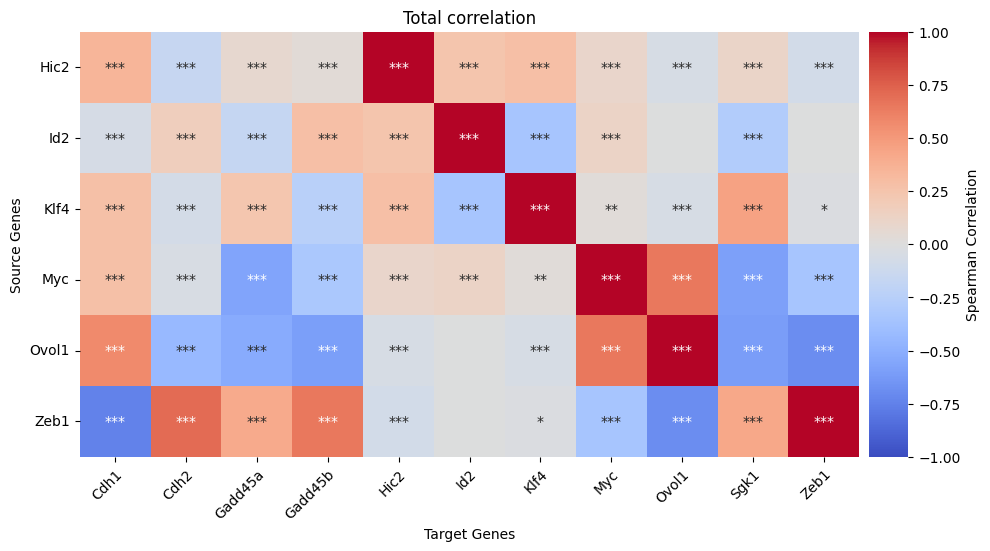

In [274]:
single_cell_analysis.plot_gene_correlation(adata, x_genes=potential_ovol1_targets, y_genes=numpy.intersect1d(tf_array, potential_ovol1_targets), annotation_style="stars", title="Total correlation")

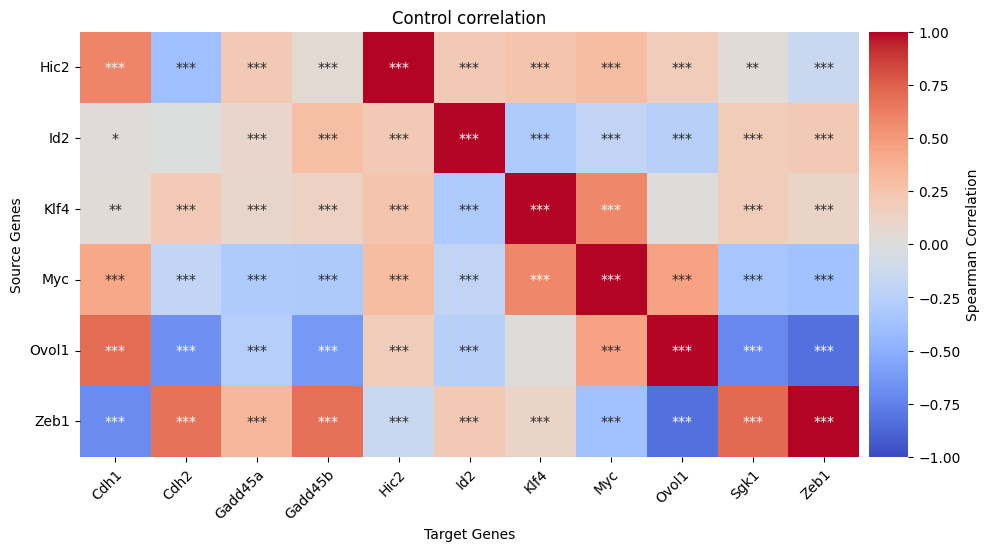

In [272]:
single_cell_analysis.plot_gene_correlation(adata, x_genes=potential_ovol1_targets, y_genes=numpy.intersect1d(tf_array, potential_ovol1_targets), annotation_style="stars", title="Control correlation",
group_key="group", groups="control")

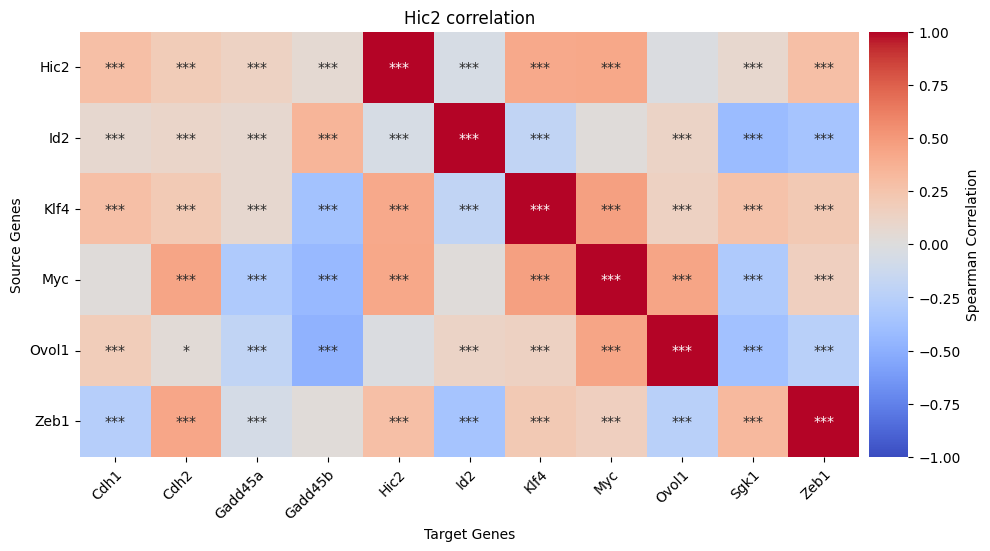

In [ ]:
single_cell_analysis.plot_gene_correlation(adata, x_genes=potential_ovol1_targets, y_genes=numpy.intersect1d(tf_array, potential_ovol1_targets), annotation_style="stars", title="Hic2 correlation",
    group_key="group", groups="Hic2")

In [287]:
# Compare with collectri

def plot_regulatory_interactions(collectri_dataframe, x_genes, y_genes, figsize=(10, 8), title=""):
    
    # filter the database for the specified source and target genes
    filtered_dataframe = collectri_dataframe[
        (collectri_dataframe["source"].isin(y_genes)) & 
        (collectri_dataframe["target"].isin(x_genes))
    ]
    
    # reshape the dataframe into an adjacency matrix
    # aggregate duplicate interactions by taking the mean to handle conflicting references if they exist
    interaction_matrix = filtered_dataframe.pivot_table(
        index="source", 
        columns="target", 
        values="weight", 
        aggfunc="mean",
        fill_value=0.0
    )
    
    # reindex the matrix to include all requested genes, filling missing genes with zero
    interaction_matrix = interaction_matrix.reindex(index=y_genes, columns=x_genes, fill_value=0.0)
    
    # initialize the figure canvas and axis
    figure, axis = matplotlib.pyplot.subplots(figsize=figsize)

    # create an axes divider mapped to the main axis to ensure the colorbar matches the height
    divider = mpl_toolkits.axes_grid1.make_axes_locatable(axis)
    colorbar_axis = divider.append_axes("right", size="5%", pad=0.1)

    # plot the heatmap mapping the colorbar to the newly appended axis
    seaborn.heatmap(
        data=interaction_matrix,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        xticklabels=True,
        yticklabels=True,
        ax=axis,
        cbar_ax=colorbar_axis,
        cbar_kws={"label": "Regulatory Weight"}
    )

    # apply axis labels
    axis.set_xlabel("Target Genes")
    axis.set_ylabel("Source Genes")

    # rotate the x-axis tick labels to prevent text overlap
    axis.set_xticklabels(axis.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # ensure y-axis labels are horizontal
    axis.set_yticklabels(axis.get_yticklabels(), rotation=0)

    axis.set_title(title)

    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

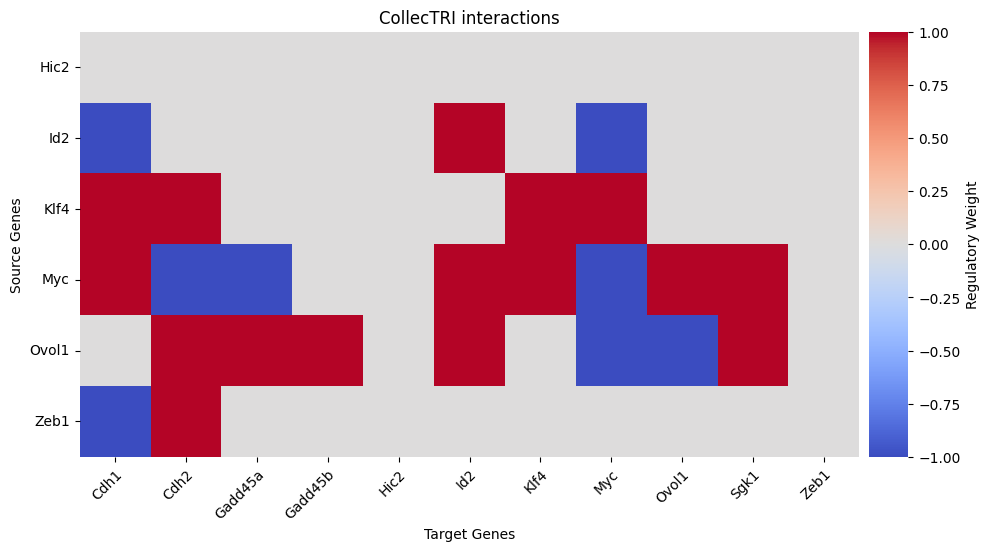

In [288]:
plot_regulatory_interactions(collectri_df, potential_ovol1_targets, numpy.intersect1d(tf_array, potential_ovol1_targets), title="CollecTRI interactions")